   #  Exploratory Data Analysis On E-Commerce Sales

In [1]:
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.style.use('ggplot')
    sns.set_palette('deep')

In [2]:
    df=pd.read_csv(r"C:\Users\Sahil Singh\Sam_Analysis\03_Project_E-Commerce_Data(EDA)/E-Commerce_Sales_Data_2024-25.csv")

# Understanding Dataset 

In [3]:
    #Displays first 10 rows.
    df.head(10)  # Dataset contains order-level sales information.

,Order ID,Order Date,Customer Name,City,Category,Product Name,Quantity,Unit Price,status,Payment Mode
0,10001,10/19/2024,Kashvi Varty,Bangalore,Books,Non-Fiction Ipsum,2,36294,Cancelled,Debit Card
1,10002,8/30/2025,Advik Desai,Delhi,Groceries,Rice Nemo,1,42165,Shipped - Delivered to Buyer,Debit Card
2,10003,11/4/2023,Rhea Kalla,Patna,Kitchen,Juicer Odio,4,64876,Shipped,Credit Card
3,10004,5/23/2025,Anika Sen,Kolkata,Groceries,Oil Doloribus,5,37320,Cancelled,UPI
4,10005,1/19/2025,Akarsh Kaul,Pune,Clothing,Kids Wear Quo,1,50037,Shipped,Debit Card
5,10006,4/6/2025,Vardaniya Jayaraman,Pune,Furniture,Chair Assumenda,5,40287,Shipped,Credit Card
6,10007,10/13/2023,Drishya Khare,Mumbai,Clothing,Accessories Minima,2,3636,Shipped,Debit Card
7,10008,8/17/2025,Misha Dua,Lucknow,Books,Biography Vel,1,15885,Shipped - Delivered to Buyer,Debit Card
8,10009,3/7/2025,Arhaan Vala,Jaipur,Groceries,Spices Expedita,1,40834,Cancelled,Credit Card
9,10010,12/2/2024,Lavanya Hayer,Goa,Kitchen,Juicer Voluptatibus,2,16686,Shipped,UPI


In [4]:
    #Check last rows
    df.tail() 

,Order ID,Order Date,Customer Name,City,Category,Product Name,Quantity,Unit Price,status,Payment Mode
4995,14996,6/25/2024,Nishith Kulkarni,Kolkata,Books,Fiction Veritatis,3,60671,Shipped,Debit Card
4996,14997,12/22/2024,Aaina Chander,Jaipur,Toys,Doll Nulla,5,70048,Shipped - Delivered to Buyer,Credit Card
4997,14998,4/15/2025,Dhanush Gara,Bangalore,Beauty,Lipstick Eaque,1,42162,Shipped - Delivered to Buyer,Debit Card
4998,14999,7/8/2024,Divyansh Malhotra,Kolkata,Electronics,Smartwatch Adipisci,4,13568,Shipped,Credit Card
4999,15000,2/4/2024,Aarush Walla,Goa,Clothing,Kids Wear Repellat,1,76762,Shipped - Delivered to Buyer,Net Banking


In [5]:
    #Check Statistical Summery
    df.describe(include='all')  #Total price distribution appears right-skewed.

,Order ID,Order Date,Customer Name,City,Category,Product Name,Quantity,Unit Price,status,Payment Mode
count,5000.000000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000,5000
unique,NaN,730,4844,20,10,3835,NaN,NaN,6,5
top,NaN,12/31/2023,Vritika Cherian,Guwahati,Books,Chair Adipisci,NaN,NaN,Shipped,Net Banking
freq,NaN,15,3,293,528,5,NaN,NaN,3031,1010
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,2.992600,39760.904600,NaN,NaN
std,1443.520003,NaN,NaN,NaN,NaN,NaN,1.413133,22831.783946,NaN,NaN
min,10001.000000,NaN,NaN,NaN,NaN,NaN,1.000000,222.000000,NaN,NaN
25%,11250.750000,NaN,NaN,NaN,NaN,NaN,2.000000,20312.250000,NaN,NaN
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,3.000000,39459.500000,NaN,NaN
75%,13750.250000,NaN,NaN,NaN,NaN,NaN,4.000000,59721.750000,NaN,NaN


In [6]:
    #Check data_types,Null_values,Memory_usage
    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Order ID       5000 non-null   int64
 1   Order Date     5000 non-null   str  
 2   Customer Name  5000 non-null   str  
 3   City           5000 non-null   str  
 4   Category       5000 non-null   str  
 5   Product Name   5000 non-null   str  
 6   Quantity       5000 non-null   int64
 7   Unit Price     5000 non-null   int64
 8   status         5000 non-null   str  
 9   Payment Mode   5000 non-null   str  
dtypes: int64(3), str(7)
memory usage: 740.4 KB


In [7]:
    #Checks column names.
    df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'City', 'Category',
       'Product Name', 'Quantity', 'Unit Price', 'status', 'Payment Mode'],
      dtype='str')

#  Data Cleaning..

In [8]:
    #Missing Values
    df.isnull().sum()  #None In this DataSet 

Order ID         0
Order Date       0
Customer Name    0
City             0
Category         0
Product Name     0
Quantity         0
Unit Price       0
status           0
Payment Mode     0
dtype: int64

In [9]:
    # Duplicate Values
    df.duplicated().sum()   # None in this dataset

np.int64(0)

In [10]:
    # Dropping columns
    df.drop('Order ID',axis=1,inplace=True)

In [11]:
    # Standardize the data
    df.columns=df.columns.str.lower().str.strip().str.replace(' ','_')
    df=df.rename(columns={'unit_price':'price'})
    df.columns

Index(['order_date', 'customer_name', 'city', 'category', 'product_name',
       'quantity', 'price', 'status', 'payment_mode'],
      dtype='str')

In [12]:
    # Fixing Data types 
    # Here, Order date columns show Str 
    df['order_date']=pd.to_datetime(df['order_date'], format="mixed")
    df['order_date'].dtype

dtype('<M8[us]')

In [13]:
    # Feature Engineering 
    df['order_month']=df['order_date'].dt.month_name()
    df['order_year']=df['order_date'].dt.year
    df['order_month'].head()
    df['order_year'].head()

0    2024
1    2025
2    2023
3    2025
4    2025
Name: order_year, dtype: int32

In [14]:
    df['total_price']=df['price']*df['quantity']  #Important for KPIs
    df['total_price'].head()

0     72588
1     42165
2    259504
3    186600
4     50037
Name: total_price, dtype: int64

# Analysis

In [15]:
    #Uninvariate Analysis 

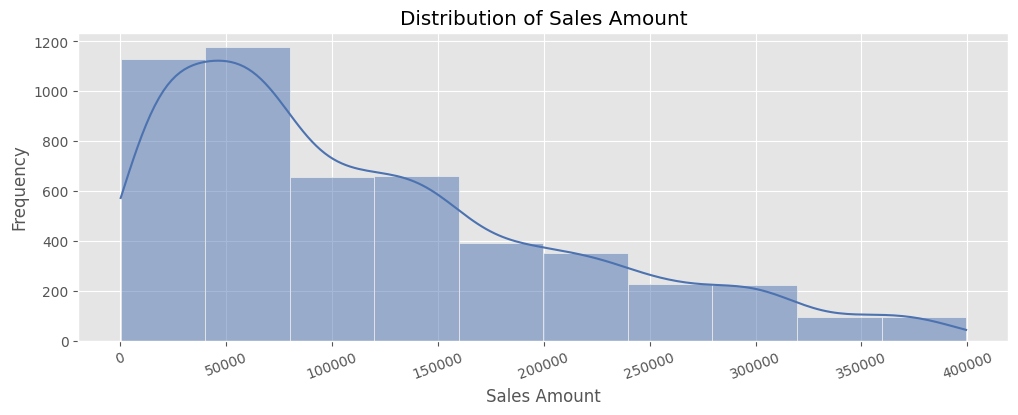

In [16]:
    plt.figure(figsize=(12,4))
    sns.histplot(df['total_price'],bins=10,kde=True)
    plt.title('Distribution of Sales Amount')
    plt.xlabel('Sales Amount')
    plt.ylabel('Frequency')
    plt.xticks(rotation=20)
    plt.show()

In [17]:
    #Insight
    #Most orders are low-value, Few orders are high-value & Right-skewed distribution

In [18]:
    #Check Category Frequency
    df['category'].value_counts()

category
Books          528
Kitchen        528
Furniture      527
Home Decor     515
Clothing       511
Sports         511
Toys           478
Electronics    472
Groceries      470
Beauty         460
Name: count, dtype: int64

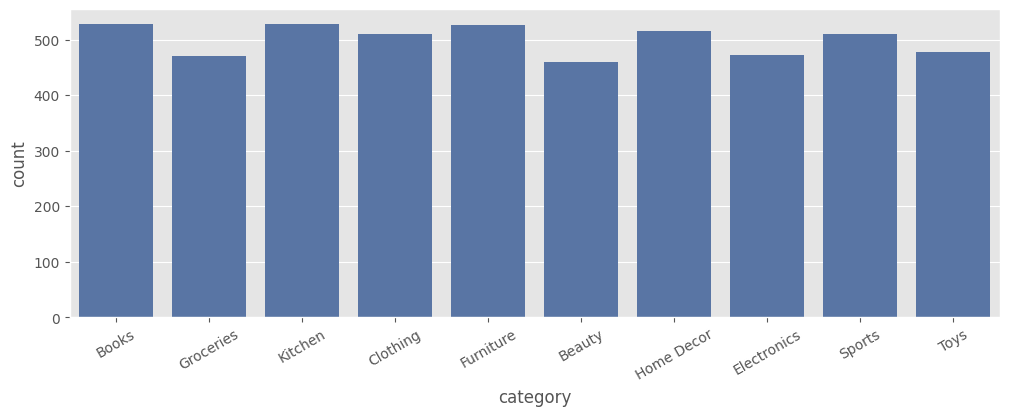

In [19]:
    plt.figure(figsize=(12,4))
    sns.countplot(x='category', data=df)
    plt.xticks(rotation=30)
    plt.show()

In [20]:
    #Insight
    #Shows which product categories dominate sales volume.

Text(0.5, 1.0, 'Quantity Purchased Analysis')

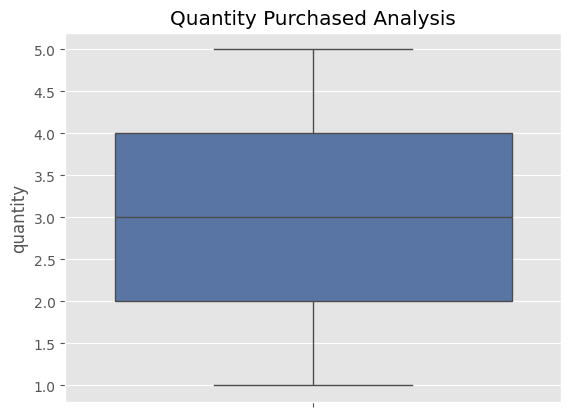

In [21]:
    sns.boxplot(df['quantity'])
    plt.title('Quantity Purchased Analysis')

In [22]:
    #Insight
    #Most customers purchase products in small-to-medium quantities.
    #A small number of transactions contain significantly higher quantities, creating visible outliers.

In [23]:
    # Multivariate Analysis

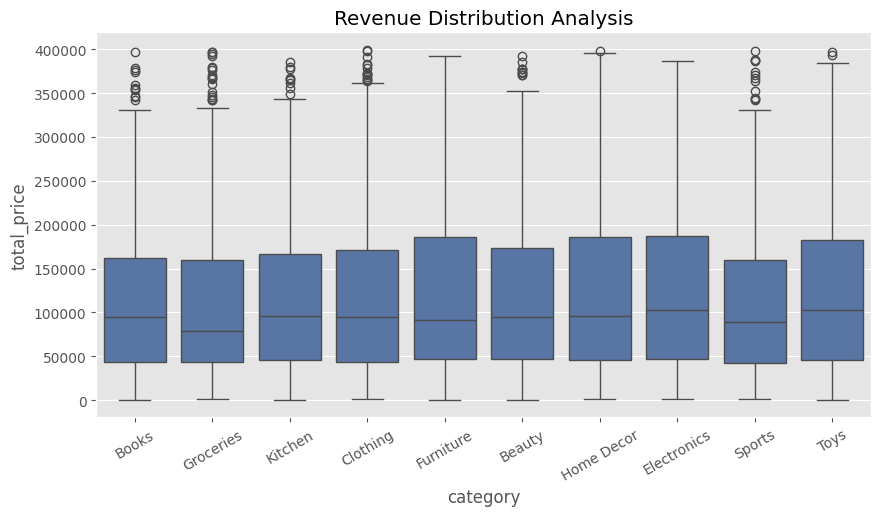

In [24]:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='category', y='total_price', data=df)
    plt.title('Revenue Distribution Analysis')
    plt.xticks(rotation=30)
    plt.show()

In [25]:
    #Insight
    #The majority of customers generate average transaction values
    #A smaller group of premium customers contributes a disproportionately high share of revenue

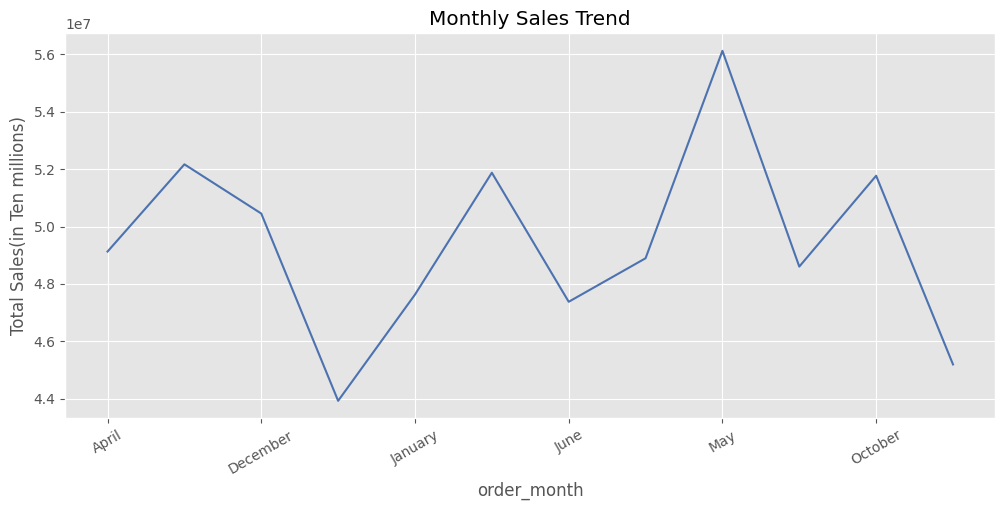

In [26]:
    month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
    ]
    monthly_sales = df.groupby('order_month')['total_price'].sum()
    monthly_sales.plot(figsize=(12,5))
    plt.title('Monthly Sales Trend')
    plt.ylabel('Total Sales(in Ten millions)')
    plt.xticks(rotation=30)
    plt.show()

In [27]:
    #Insights
    #May recorded the highest monthly sales revenue
    #Certain months experienced lower revenue performance, indicating seasonal demand variations

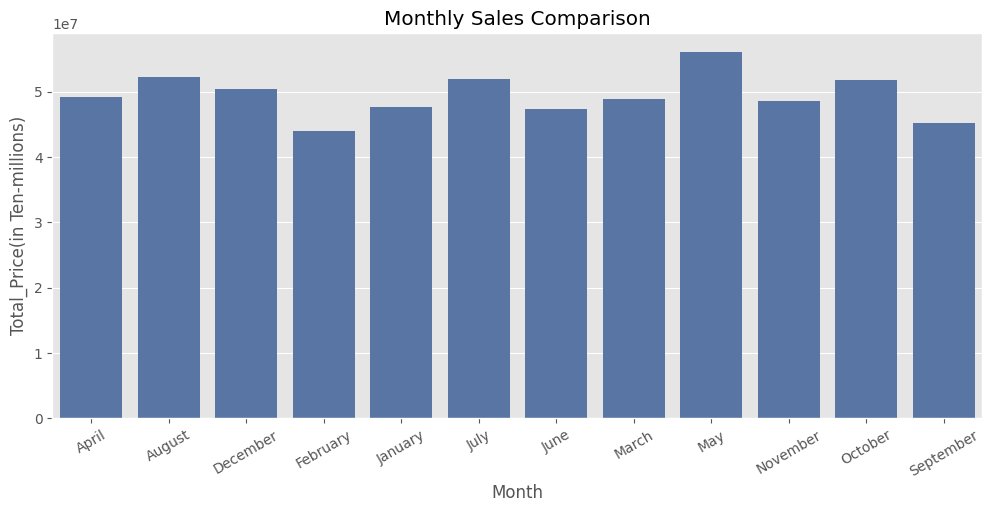

In [28]:
    monthly_sales = df.groupby('order_month')['total_price'].sum().reset_index()
    plt.figure(figsize=(12,5))
    sns.barplot(x='order_month',y='total_price',data=monthly_sales)
    plt.title('Monthly Sales Comparison')
    plt.xlabel('Month')
    plt.ylabel('Total_Price(in Ten-millions)')
    plt.xticks(rotation=30)
    plt.show()

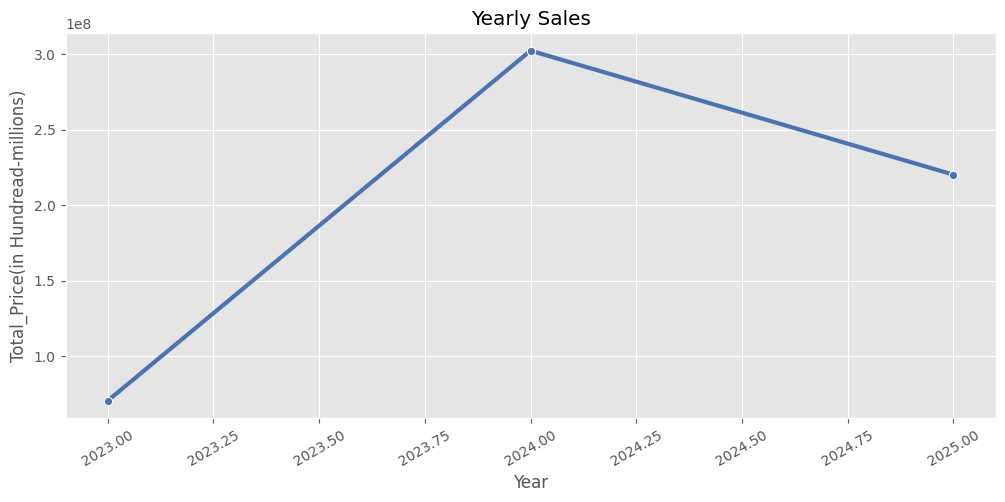

In [29]:
    yearly_sales = df.groupby('order_year')['total_price'].sum().reset_index()
    plt.figure(figsize=(12,5))
    sns.lineplot(x='order_year',y='total_price',data=yearly_sales,marker='o', linewidth=3)
    plt.title('Yearly Sales')
    plt.xlabel('Year')
    plt.ylabel('Total_Price(in Hundread-millions)')
    plt.xticks(rotation=30)
    plt.show()

In [30]:
    #Insight
    #The yearly sales trend shows strong business growth from 2023 to 2024, followed by a moderate decline in 2025, 
    # while overall revenue remained significantly higher than the initial year.


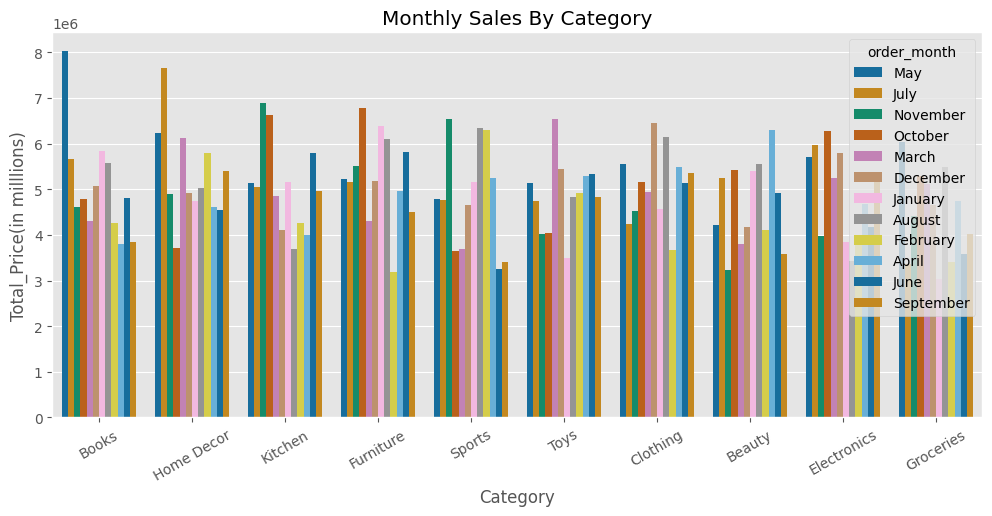

In [31]:
    monthly_sales = df.groupby(['category','order_month'])['total_price'].sum().reset_index()
    monthly_sales=monthly_sales.sort_values('total_price',ascending=False)
    plt.figure(figsize=(12,5))
    sns.barplot(x='category',y='total_price',data=monthly_sales,hue='order_month',palette='colorblind',legend='brief')
    plt.title('Monthly Sales By Category')
    plt.xlabel('Category')
    plt.ylabel('Total_Price(in milllions)')
    plt.xticks(rotation=30)
    plt.show()

In [32]:
    #Insight 
    # Book category contributes higher in revenue, closely followed by Home Decor category.

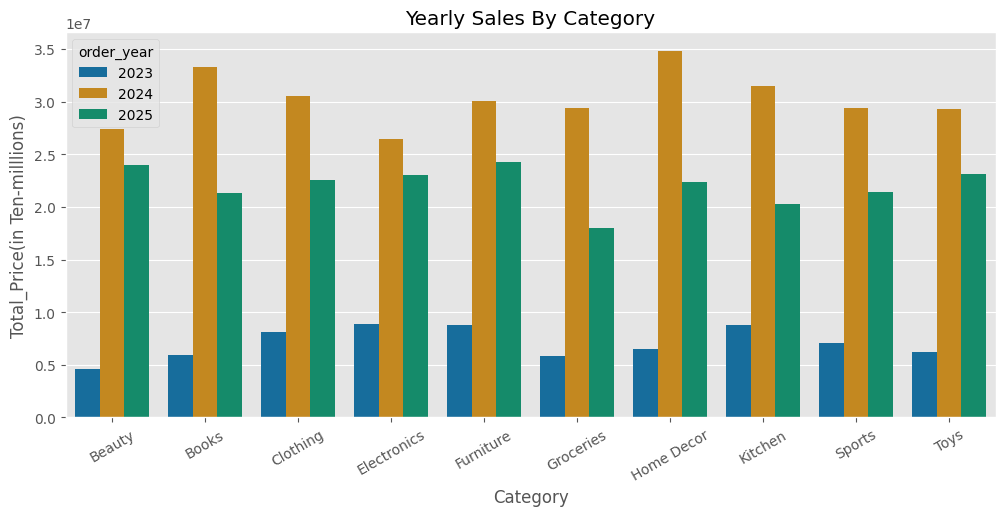

In [33]:
    plt.figure(figsize=(12,5))
    yearly_sales = df.groupby(['category','order_year'])['total_price'].sum().reset_index()
    sns.barplot(x='category',y='total_price',data=yearly_sales,hue='order_year',palette='colorblind')
    plt.title('Yearly Sales By Category')
    plt.xlabel('Category')
    plt.ylabel('Total_Price(in Ten-milllions)')
    plt.xticks(rotation=30)
    plt.show()

In [34]:
    #Insight
    #Sales peaked across almost all categories in 2024—especially Home Decor and Books—while 2025 shows a noticeable decline,
    #with Groceries experiencing the sharpest drop.

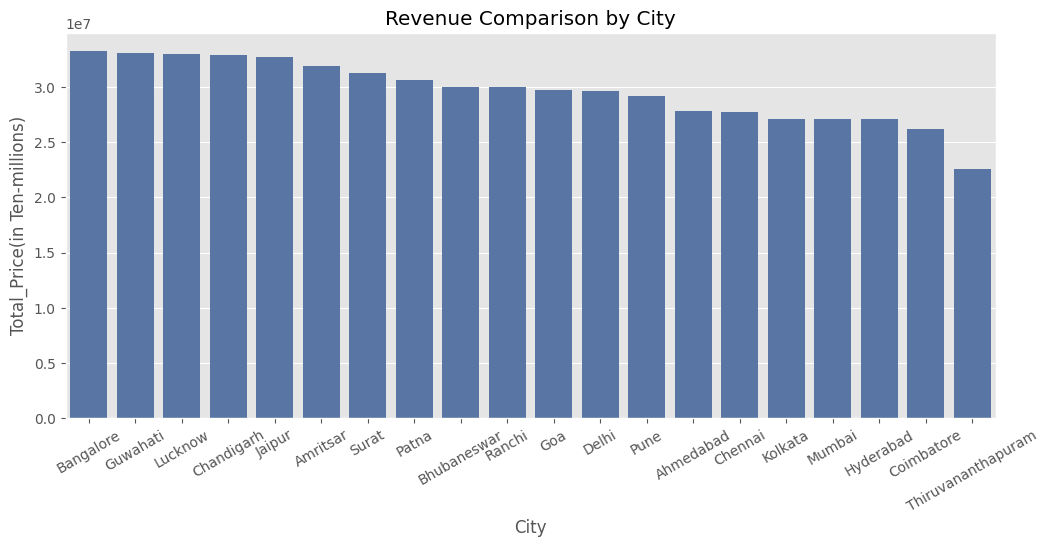

In [35]:
       
    monthly_sales = df.groupby('city')['total_price'].sum().reset_index()
    monthly_sales=monthly_sales.sort_values('total_price',ascending=False)
    plt.figure(figsize=(12,5))
    sns.barplot(x='city',y='total_price',data=monthly_sales)
    plt.title('Revenue Comparison by City')
    plt.xlabel('City')
    plt.ylabel('Total_Price(in Ten-millions)')
    plt.xticks(rotation=30)
    plt.show()

In [36]:
    #Insight
    #Bangalore generated the highest sales revenue among all cities, while Thiruvananthapuram recorded the lowest sales performance.
    #Overall, sales distribution across cities remained relatively balanced, indicating stable market demand across multiple regions.


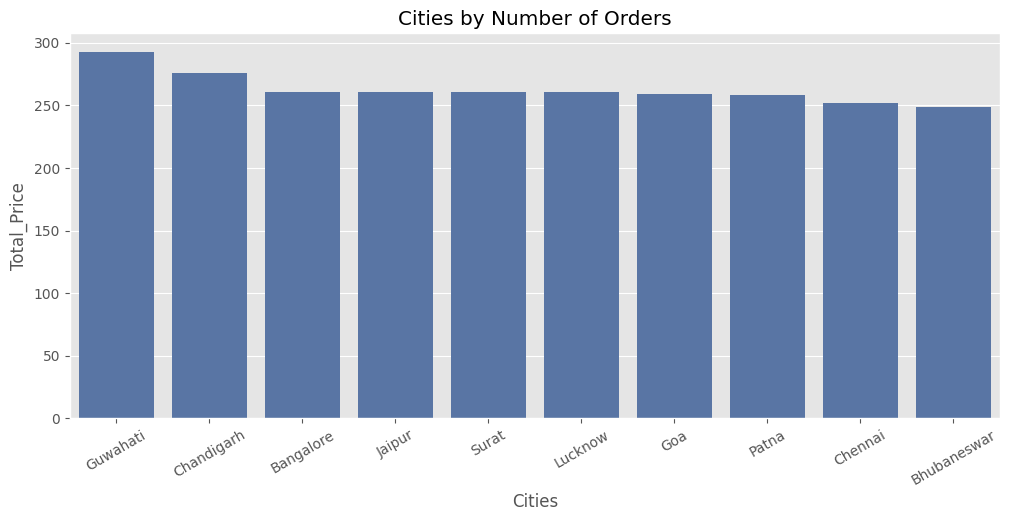

In [37]:
    plt.figure(figsize=(12,5))
    city_sales = df.groupby('city')['total_price'].count().reset_index()
    city_sales = city_sales.sort_values('total_price', ascending=False).head(10)
    sns.barplot(x='city',y='total_price',data=city_sales)
    plt.title('Cities by Number of Orders')
    plt.xlabel('Cities')
    plt.ylabel('Total_Price')
    plt.xticks(rotation=30)
    plt.show()

In [38]:
    #Insight
    #Guwahati shows higher number of orders,closely followed by Chandigarh and other cities

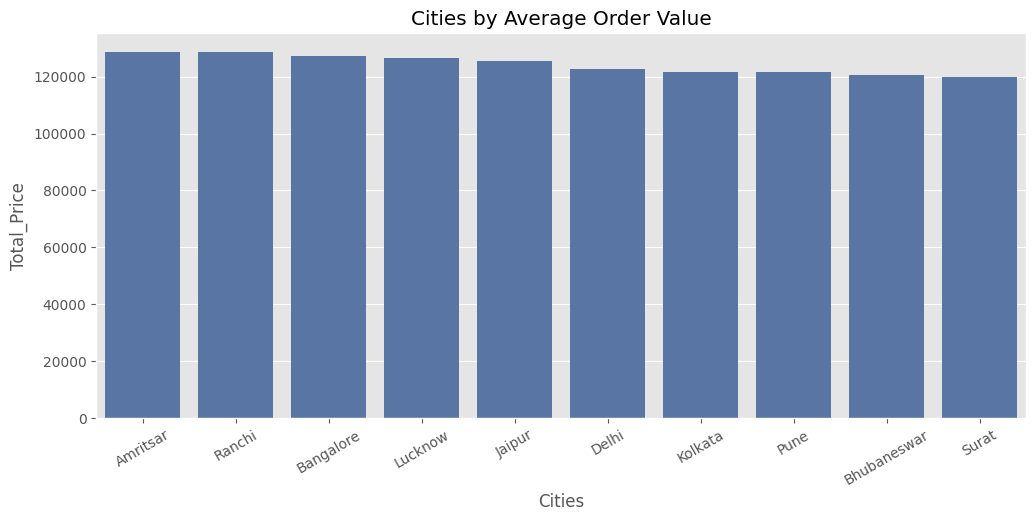

In [39]:
    plt.figure(figsize=(12,5))
    city_sales = df.groupby('city')['total_price'].mean().reset_index()
    city_sales = city_sales.sort_values('total_price', ascending=False).head(10)
    sns.barplot(x='city',y='total_price',data=city_sales)
    plt.title('Cities by Average Order Value')
    plt.xlabel('Cities')
    plt.ylabel('Total_Price')
    plt.xticks(rotation=30)
    plt.show()

In [40]:
    #Insight
    #AOV of Top cities are mainly same

<Axes: >

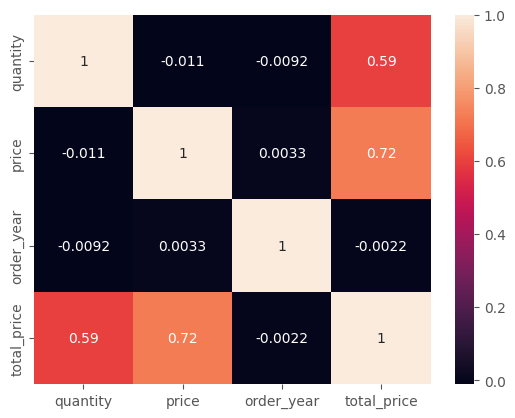

In [41]:
    sns.heatmap(df.corr(numeric_only=True), annot=True)

In [42]:
    #Insight
    #Total price is strongly positively correlated with price (0.72) and moderately with quantity (0.59), 
    #while order year shows almost no relationship with the other variables.

# Business KPIs

In [43]:
#Total Revenue
Total_Revenue=df['total_price'].sum()
print(Total_Revenue)

593171089


In [44]:
#Total Order
df.shape[0]

5000

In [45]:
#Average Order Value
AOV=df['total_price'].mean()
print(AOV)

118634.2178


In [46]:
# Top City in Sales

Top_City=df.groupby('city')['total_price'].sum().idxmax()
print(Top_City)

Bangalore


In [47]:
# Top Month in Sales
Top_Month=df.groupby('order_month')['total_price'].sum().idxmax()
print(Top_Month)

May


In [48]:
#Top 5 Customers in Spending
Top_Customers=df.groupby('customer_name') ['total_price'].sum().sort_values(ascending=False).head(5)
print(Top_Customers)

customer_name
Aaryahi Madan    722391
Bhamini Sane     538161
Samarth Wagle    524785
Badal Rao        509935
Arhaan Basu      506272
Name: total_price, dtype: int64


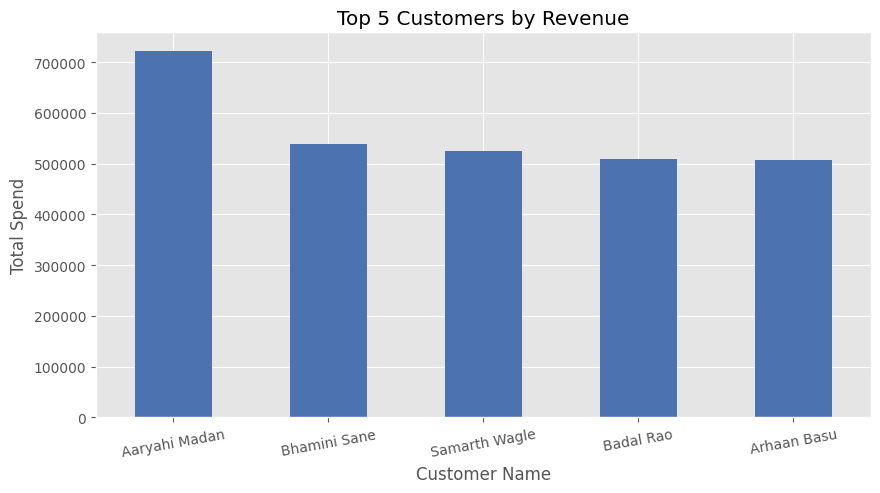

In [49]:
top_customers = df.groupby('customer_name')['total_price'].sum().sort_values(ascending=False).head(5)

top_customers.plot(kind='bar', figsize=(10,5))

plt.title('Top 5 Customers by Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Total Spend')
plt.xticks(rotation=10)

plt.show()

# Final Conclusion

# Recommended Business Actions